# Lab 6: Logistic Regression & KNN Classification

**Name:** Haseeb Hassan

**Student ID:** 023-24-0274

**Section:** H

**GitHub Profile:** [Haseeb-Hassan66](https://github.com/Haseeb-Hassan66)

**Kaggle Profile:** [haseebsamo66737](https://www.kaggle.com/haseebsamo66737)

**Dataset:** Telco Customer Churn (cleaned in Lab 2 — `clean_churn.csv`)

**Dataset Source:** [Telco Customer Churn — Kaggle](https://github.com/Haseeb-Hassan66/ML-Practice/blob/main/Week%202/telco-churn.csv)

---

## Part 1 — Problem Definition & Dataset Verification

**Tasks 1–2**

1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [1]:
# Task 1 — load and verify the cleaned dataset from Lab 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values remaining:", df.isnull().sum().sum())
df.head()

Shape: (7043, 20)

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values remaining: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,Yes,43,Yes,Yes,Fiber Optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.30,4209.95,No
1,Male,0,Yes,Yes,67,Yes,Yes,Fiber Optic,Yes,Yes,No,Yes,No,No,One year,No,Electronic check,89.55,6038.55,No
2,Female,1,No,No,1,Yes,No,Fiber Optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,71.15,71.15,Yes
3,Female,1,Yes,No,72,Yes,Yes,Dsl,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),89.85,6697.35,No
4,Female,0,No,No,69,Yes,No,Dsl,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),82.45,5555.30,No


**Answer 2 (Lab 3/4 benchmarks):**

In Lab 3, my chosen Decision Tree (`max_depth=4`, gini) got **78.35% accuracy, 58.56% precision, 63.10% recall, and 60.75% F1-score** on the test set. In Lab 4, the default Random Forest (`n_estimators=200`) got **78.14% accuracy, 60.86% precision, 49.47% recall, and 54.57% F1-score**. These two results are today's benchmarks — Logistic Regression and KNN need to be compared against them.

---

## Part 2 — Feature Scaling & Preparation

**Tasks**

3. Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [2]:
# Task 3 — prepare X and y exactly as in Lab 3/4
# Encode the target variable: No = 0, Yes = 1
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Remove the target column from the features
X = df.drop(columns=['Churn'])

# One-hot encode the categorical columns (same as Lab 3/4)
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Categorical columns encoded:", cat_cols)
print("\nFinal X shape:", X.shape)
print("Missing values in X:", X.isnull().sum().sum())
X.head()

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Final X shape: (7043, 30)
Missing values in X: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,43,99.30,4209.95,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
1,0,67,89.55,6038.55,True,True,True,True,False,True,...,False,False,False,False,True,False,False,False,True,False
2,1,1,71.15,71.15,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,72,89.85,6697.35,False,True,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
4,0,69,82.45,5555.30,False,False,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False


**Answer 4 (why scaling matters here but not for trees):**

KNN works by measuring the straight-line distance between points, so a feature like `TotalCharges` (which can be in the thousands) would completely dominate a feature like `SeniorCitizen` (which is just 0 or 1) unless everything is put on the same scale. Logistic Regression also cares about scale because its coefficients and the gradient descent it uses during training get skewed by features with much bigger ranges. Decision Trees and Random Forests don't have this problem because they just pick a threshold to split on for each feature one at a time — the actual scale of the numbers doesn't change where a good split point is.

In [3]:
# Task 5 — train/test split (same strategy as Lab 3/4) + StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Fit the scaler on the training data ONLY, then apply it to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. X_train_scaled shape:", X_train_scaled.shape)

X_train shape: (5634, 30)
X_test shape: (1409, 30)

Scaling done. X_train_scaled shape: (5634, 30)


**Answer 5 (why fit the scaler on training data only):**

If I fit the scaler on the whole dataset (train + test combined), the mean and standard deviation used for scaling would already "see" information from the test set. That's a form of data leakage — the model would get an unfair sneak peek at the test data's distribution before evaluation. Fitting the scaler only on `X_train` and then just applying (`transform`) that same scaling to `X_test` keeps the test set truly unseen, which gives a fair estimate of how the model would perform on new customers.

---

## Part 3 — Logistic Regression

**Tasks**

6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [4]:
# Task 6 — train Logistic Regression on the scaled data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)

logreg_pred = logreg_model.predict(X_test_scaled)

print("Logistic Regression trained.")

Logistic Regression trained.


      Metric   Value
0   Accuracy  0.7942
1  Precision  0.6257
2     Recall  0.5588
3   F1-score  0.5904

Confusion matrix:
 [[910 125]
 [165 209]]


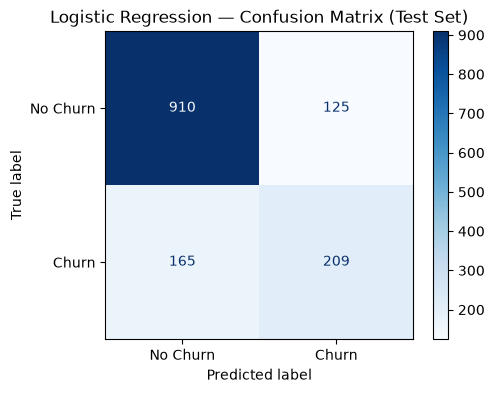

In [5]:
# Task 7 — accuracy, precision, recall, F1 + confusion matrix
lr_acc = accuracy_score(y_test, logreg_pred)
lr_prec = precision_score(y_test, logreg_pred)
lr_rec = recall_score(y_test, logreg_pred)
lr_f1 = f1_score(y_test, logreg_pred)

logreg_metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [round(lr_acc, 4), round(lr_prec, 4), round(lr_rec, 4), round(lr_f1, 4)]
})
print(logreg_metrics_table)

cm_lr = confusion_matrix(y_test, logreg_pred)
print("\nConfusion matrix:\n", cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Logistic Regression — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 7):**

The Logistic Regression model got **79.42% accuracy, 62.57% precision, 55.88% recall, and 59.04% F1-score** on the test set. Looking at the confusion matrix, it correctly caught 209 of the 374 actual churners and missed 165 of them, while raising 125 false alarms. Compared to Lab 3's Decision Tree, Logistic Regression has better accuracy and precision, but a bit lower recall — so it's slightly more cautious about predicting "Churn."

**Answer 8 (what predict_proba represents):**

`predict_proba` gives two probabilities for each customer — the estimated probability they belong to class 0 (No Churn) and class 1 (Churn), and the two always add up to 1. `predict()` just applies a 0.5 threshold: if the probability of Churn is above 0.5, it predicts "Yes," otherwise it predicts "No." 

In [6]:
# Task 8 — look at predict_proba for a handful of test customers
proba_sample = logreg_model.predict_proba(X_test_scaled)[:5]
pred_sample = logreg_model.predict(X_test_scaled)[:5]

proba_table = pd.DataFrame({
    "P(No Churn)": proba_sample[:, 0].round(4),
    "P(Churn)": proba_sample[:, 1].round(4),
    "Predicted Class": np.where(pred_sample == 1, "Yes", "No")
})
proba_table

,P(No Churn),P(Churn),Predicted Class
0,0.5221,0.4779,No
1,0.8727,0.1273,No
2,0.9830,0.0170,No
3,0.5673,0.4327,No
4,0.9809,0.0191,No


---

## Part 4 — KNN & Choosing K

**Tasks**

9. Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [7]:
# Task 9 — try several K values and record accuracy + F1
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)

    knn_results.append({
        "K": k,
        "Test Accuracy": round(accuracy_score(y_test, pred_k), 4),
        "Test F1-score": round(f1_score(y_test, pred_k), 4)
    })

knn_results_table = pd.DataFrame(knn_results)
knn_results_table

,K,Test Accuracy,Test F1-score
0,1,0.7012,0.4637
1,3,0.7275,0.4934
2,5,0.7445,0.5276
3,7,0.7594,0.5474
4,9,0.7622,0.5417
5,11,0.7686,0.5606
6,15,0.7601,0.5408
7,21,0.7686,0.5583


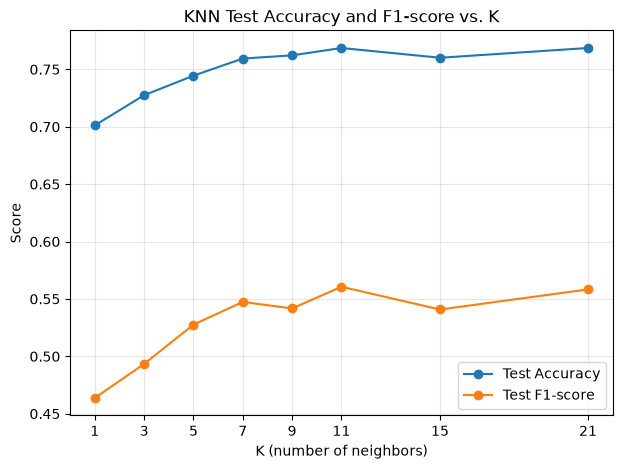

In [8]:
# Task 10 — plot accuracy and F1-score against K
plt.figure(figsize=(7, 5))
plt.plot(knn_results_table["K"], knn_results_table["Test Accuracy"], marker='o', label='Test Accuracy')
plt.plot(knn_results_table["K"], knn_results_table["Test F1-score"], marker='o', label='Test F1-score')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Score')
plt.title('KNN Test Accuracy and F1-score vs. K')
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Answer 10 (choosing K):**

I'm choosing **K = 11**. It gets the highest F1-score (0.5606) out of all the values I tried, and it's tied for the highest accuracy (0.7686) with K=21. I'm not picking K=1 because a single neighbor is very sensitive to noise and basically memorizes the training data (overfitting), and I'm not picking the largest K=21 either, because larger K values start averaging over too many neighbors that aren't actually similar to the customer, which can underfit and blur the decision boundary. K=11 sits at a good balance between the two extremes and gives the best result on the metric I care about most here (F1).

      Metric   Value
0   Accuracy  0.7686
1  Precision  0.5652
2     Recall  0.5561
3   F1-score  0.5606

Confusion matrix:
 [[875 160]
 [166 208]]


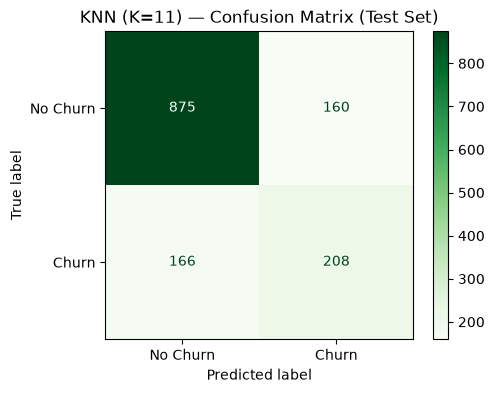

In [9]:
# Task 11 — final KNN model with the chosen K=11
best_k = 11
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_pred = knn_final.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred)
knn_rec = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

knn_final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [round(knn_acc, 4), round(knn_prec, 4), round(knn_rec, 4), round(knn_f1, 4)]
})
print(knn_final_metrics)

cm_knn = confusion_matrix(y_test, knn_pred)
print("\nConfusion matrix:\n", cm_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Greens", values_format='d')
plt.title(f"KNN (K={best_k}) — Confusion Matrix (Test Set)")
plt.show()

**Observation (Task 11):**

The final KNN model (K=11) got **76.86% accuracy, 56.52% precision, 55.61% recall, and 56.06% F1-score**. From the confusion matrix, it correctly caught 208 of the 374 actual churners and missed 166, with 160 false alarms. This is a bit weaker than both the Decision Tree and Logistic Regression on most metrics, but it's still a reasonable classifier once the features are properly scaled.

---

## Part 5 — Model Comparison (4 Models)

**Tasks**

12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [10]:
# Task 12 — retrain Decision Tree (Lab 3) and Random Forest (Lab 4) on the SAME split
# so all four models are compared fairly on this notebook's train/test split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

four_model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree (depth=4)": [
        round(accuracy_score(y_test, dt_pred), 4),
        round(precision_score(y_test, dt_pred), 4),
        round(recall_score(y_test, dt_pred), 4),
        round(f1_score(y_test, dt_pred), 4)
    ],
    "Random Forest (default)": [
        round(accuracy_score(y_test, rf_pred), 4),
        round(precision_score(y_test, rf_pred), 4),
        round(recall_score(y_test, rf_pred), 4),
        round(f1_score(y_test, rf_pred), 4)
    ],
    "Logistic Regression": [round(lr_acc, 4), round(lr_prec, 4), round(lr_rec, 4), round(lr_f1, 4)],
    "KNN (K=11)": [round(knn_acc, 4), round(knn_prec, 4), round(knn_rec, 4), round(knn_f1, 4)]
})
four_model_comparison

,Metric,Decision Tree (depth=4),Random Forest (default),Logistic Regression,KNN (K=11)
0,Accuracy,0.7835,0.7814,0.7942,0.7686
1,Precision,0.5856,0.6086,0.6257,0.5652
2,Recall,0.6310,0.4947,0.5588,0.5561
3,F1-score,0.6075,0.5457,0.5904,0.5606


**Answer 13 (best model overall):**

The ranking definitely changes depending on the metric. Logistic Regression has the best **accuracy** (79.42%) and best **precision** (62.57%), but the Decision Tree has the best **recall** (63.10%) and best **F1-score** (60.75%). Random Forest and KNN don't lead on any metric here. Given the class imbalance from Lab 2 (about 73% No / 27% Yes), accuracy on its own isn't very trustworthy, since a model can already look decent just by guessing "No" most of the time. For a churn problem, **recall and F1-score matter the most**, because the real business goal is to actually catch customers who are about to leave — missing a churner is more costly than a false alarm. On that basis, the Decision Tree still comes out slightly ahead, with Logistic Regression as a close second.

---

## Part 6 — Coefficient Interpretation

**Tasks**

14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning, holding other features constant").
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [11]:
# Task 14 — extract Logistic Regression coefficients and convert to odds ratios
coef_series = pd.Series(logreg_model.coef_[0], index=X.columns)
odds_ratio = np.exp(coef_series)

coef_table = pd.DataFrame({
    "Coefficient": coef_series.round(4),
    "Odds Ratio": odds_ratio.round(4)
})
coef_table = coef_table.reindex(coef_series.abs().sort_values(ascending=False).index)

coef_table.head(10)

,Coefficient,Odds Ratio
tenure,-1.2922,0.2747
Contract_Two year,-0.6181,0.5390
TotalCharges,0.4945,1.6398
InternetService_Fiber Optic,0.4479,1.5650
Contract_One year,-0.2575,0.7730
PaperlessBilling_Yes,0.2036,1.2258
OnlineSecurity_Yes,-0.1847,0.8313
StreamingMovies_Yes,0.1401,1.1504
MultipleLines_Yes,0.1377,1.1476
TechSupport_Yes,-0.1374,0.8717


**Interpretation of Task 14 (at least 4 features):**

- **tenure** — coefficient -1.29, odds ratio 0.27. Longer-tenure customers have much lower odds of churning; each one-standard-deviation increase in tenure cuts the odds of churning to roughly 27% of what they were, holding everything else constant. This is by far the strongest effect in the whole model.
- **Contract_Two year** — coefficient -0.62, odds ratio 0.54. Customers on a two-year contract have roughly **0.54× (about 46% lower)** odds of churning compared to a month-to-month customer, holding other features constant.
- **TotalCharges** — coefficient +0.49, odds ratio 1.64. Higher TotalCharges is linked with roughly **1.64× higher** odds of churning, holding other features constant — this is a bit counter-intuitive at first, but it's probably picking up customers who've been billed a lot in a short time (e.g. high monthly charges) rather than pure loyalty.
- **InternetService_Fiber Optic** — coefficient +0.45, odds ratio 1.57. Fiber-optic customers have roughly **1.57× higher** odds of churning than customers on the baseline internet service, holding other features constant — this matches the pattern seen throughout the course that fiber customers are less happy/more price-sensitive.
- **Contract_One year** — coefficient -0.26, odds ratio 0.77. One-year contract customers have roughly **0.77× (about 23% lower)** odds of churning than month-to-month customers, though the effect is smaller than the two-year contract.

**Answer 15 (agreement with Lab 2 EDA / Lab 3 feature importances):**

Yes, there's strong agreement. Lab 3's Decision Tree found **tenure** as by far the most important feature (importance ≈0.49), followed by **InternetService_Fiber Optic** (≈0.35) and **Contract_Two year**, and Lab 2's EDA showed the same pattern — churners tend to have low tenure, fiber internet, and month-to-month contracts. The Logistic Regression coefficients line up with this: tenure has the single largest effect, and Contract_Two year and InternetService_Fiber Optic both show up with meaningful coefficients in the direction I'd expect (contract length lowers churn odds, fiber raises them). The one small difference is that **TotalCharges** shows up with a fairly large coefficient here, while it was a much smaller factor in the Decision Tree — Logistic Regression seems to be picking up more signal from the billing amount than the tree did.

---

## Part 7 — Final Model Selection & Conclusion

**Tasks**

16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model selection):**

I'm selecting the **Decision Tree (`max_depth=4`)** as my final model, mainly because it has the best recall (63.10%) and F1-score (60.75%) in the Part 5 table, and those are the metrics that matter most for an imbalanced churn problem. That said, Logistic Regression is close behind and actually wins on accuracy and precision, so the gap between the top two models is small. Lab 4 taught me not to trust one single train/test split too much — cross-validation there actually flipped which model looked better — so I'm treating this as "Decision Tree and Logistic Regression are both strong candidates" rather than a clear-cut win, with the Decision Tree getting the final nod because recall matters most here.

**Answer 17 (conclusion):**

Today's best model (Decision Tree, F1 = 60.75%) performs almost identically to Lab 3–4's best model, because it's literally the same Decision Tree — the new contenders, Logistic Regression and KNN, came close but didn't beat it on F1-score. Feature scaling didn't change anything for the Decision Tree or Random Forest, but it was essential for Logistic Regression and KNN to work properly, since both algorithms are sensitive to the different ranges of features like tenure and TotalCharges. Logistic Regression turned out to be a strong, simple model with the best accuracy and precision of the four, while KNN was the weakest performer overall, likely because it struggles a bit more with the high-dimensional one-hot-encoded feature space. The main limitation of the Decision Tree is that it still misses close to 40% of actual churners and its "understanding" of churn is basically driven by just two features (tenure and fiber-optic internet), so it may not generalize as well if customer behavior shifts. If I had more time, I'd try tuning the Logistic Regression's regularization strength, test `class_weight='balanced'` on all four models to push recall higher, and try combining models (e.g. a voting classifier) before locking in a final choice.

---

## Submission Checklist

- [x] Student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Source)
- [x] 1. Problem Definition & Dataset Verification
- [x] 2. Feature Scaling & Preparation (scaler fit on train only)
- [x] 3. Logistic Regression (4 metrics + confusion matrix + predict_proba explained)
- [x] 4. KNN & Choosing K (multiple K values tested, plotted, justified)
- [x] 5. Model Comparison (4 models, all 4 metrics)
- [x] 6. Coefficient Interpretation (odds ratios, ≥4 features interpreted)
- [x] 7. Final Model Selection & Conclusion
- [x] Every table/plot/metric has a short written interpretation
- [x] No SVM / Naive Bayes / other unintroduced algorithms used